# 03 — 单只股票深度分析

> ⚠️ 需先运行 `00_data_prep.ipynb` 下载真实数据，否则部分 cell 会报错

本 notebook 对任意一只 A 股进行全方位分析，涵盖：

| 模块 | 内容 |
|------|------|
| 1. 价格与成交量 | K线/均线/月度收益分布 |
| 2. 财务数据 | PE/PB历史、ROE/毛利率趋势 |
| 3. 因子暴露 | 动量/价值/质量/低波动 2×2 图 |
| 4. AI 综合分析 | 牛熊辩论（需 LLM 后端，可选）|

**只需修改第 0 节的参数，其余 cell 顺序执行即可。**

In [1]:
import sys
sys.path.insert(0, "../../..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from utils.data_loader import calc_returns

# 中文字体支持
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("✅ 导入成功")

✅ 导入成功


## Section 0 — 参数配置

**只需修改这一个 cell，其他 cell 保持不动。**

In [2]:
SYMBOL = "000001"  # 平安银行
START  = "2021-01-01"
END    = "2026-01-01"

---
## Section 1 — 价格与成交量分析

从 `utils.data_loader` 加载日线数据，绘制：
- 收盘价 + 5/20/60 日均线
- 成交量柱状图
- 月度收益率分布直方图

In [3]:
# from utils.data_loader import get_stock_history, calc_returns
from utils.local_data_loader import load_local_stock

# df = get_stock_history(SYMBOL, START, END)  # 已改用本地数据
df = load_local_stock(SYMBOL)  # 从本地 CSV 加载
df = df.loc[START:END]         # 截取日期范围

# 数据质量门
assert df.shape[0] > 100, f"数据行数异常: {df.shape[0]}"
assert df.isnull().mean().max() < 0.1, f"缺失值过多: {df.isnull().mean().max():.1%}"
assert df.index.is_monotonic_increasing, "日期未排序"
print(f"✅ 数据质量 OK | 行数: {df.shape[0]} | 时间: {df.index[0].date()} ~ {df.index[-1].date()}")
df.tail(3)

✅ 数据质量 OK | 行数: 1212 | 时间: 2021-01-04 ~ 2025-12-31


,证券代码,open,high,low,close,prev_close,volume,amount,复权状态,turnover,交易状态,pct_change,pe_ttm,pb,ps_ttm,pcf,is_st
date,,,,,,,,,,,,,,,,,
2025-12-29,sz.000001,11.54,11.62,11.50,11.56,11.54,64829542,7.490830e+08,3,0.3341,1,0.1733,5.202756,0.500768,1.652164,-5.113106,0
2025-12-30,sz.000001,11.53,11.56,11.45,11.48,11.56,58258433,6.694093e+08,3,0.3002,1,-0.6920,5.166750,0.497302,1.640730,-5.077721,0
2025-12-31,sz.000001,11.48,11.49,11.40,11.41,11.48,59062037,6.754574e+08,3,0.3044,1,-0.6098,5.135246,0.494270,1.630725,-5.046760,0


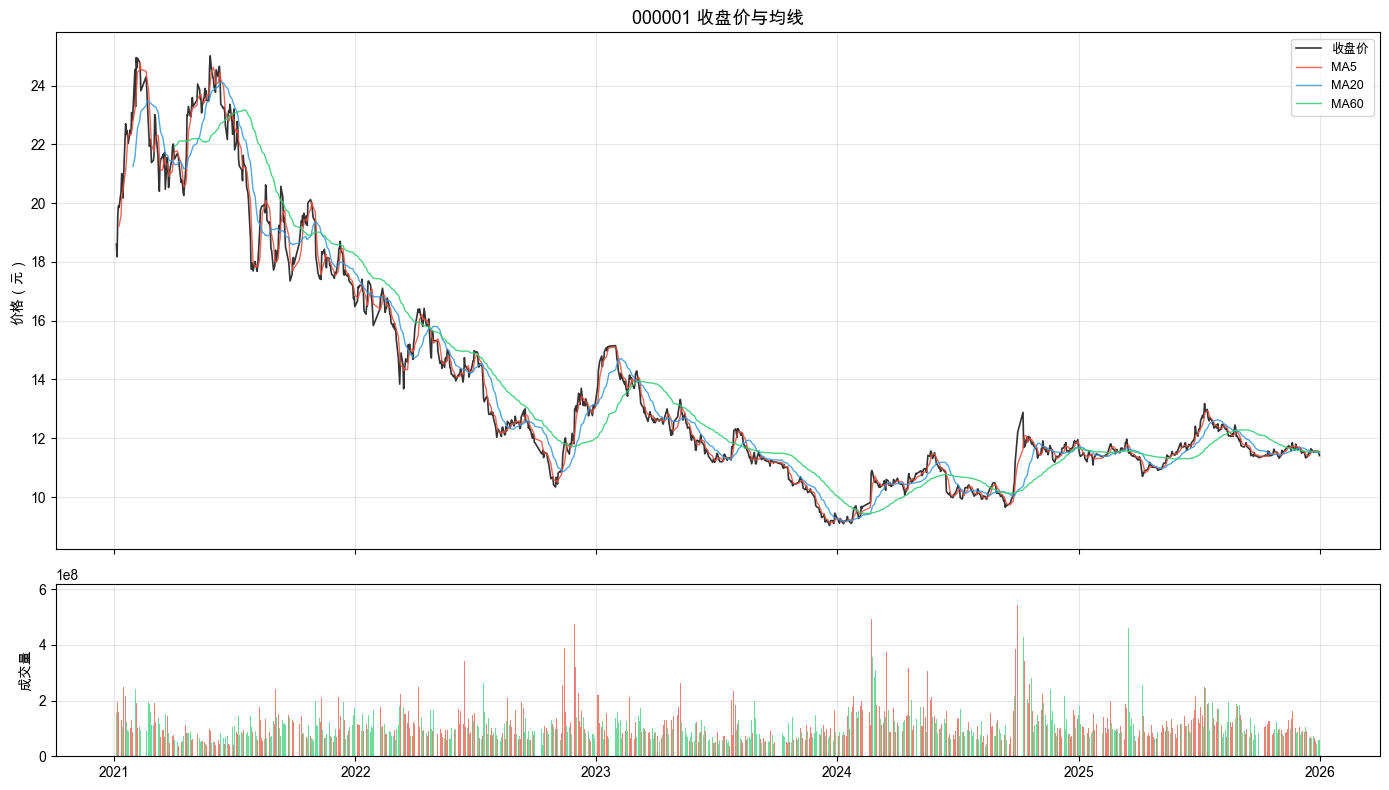

In [4]:
# 均线
close = df["close"]
ma5  = close.rolling(5).mean()
ma20 = close.rolling(20).mean()
ma60 = close.rolling(60).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

# 上图：收盘价 + 均线
ax1.plot(close.index, close, color="#333333", linewidth=1.2, label="收盘价")
ax1.plot(ma5.index,  ma5,  color="#e74c3c", linewidth=1.0, alpha=0.85, label="MA5")
ax1.plot(ma20.index, ma20, color="#3498db", linewidth=1.0, alpha=0.85, label="MA20")
ax1.plot(ma60.index, ma60, color="#2ecc71", linewidth=1.0, alpha=0.85, label="MA60")
ax1.set_title(f"{SYMBOL} 收盘价与均线", fontsize=13, fontweight="bold")
ax1.set_ylabel("价格（元）")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 下图：成交量
if "volume" in df.columns:
    vol = df["volume"]
    colors_vol = ["#e74c3c" if c >= o else "#2ecc71"
                  for c, o in zip(df["close"], df.get("open", df["close"]))]
    ax2.bar(vol.index, vol, color=colors_vol, alpha=0.7, width=1)
    ax2.set_ylabel("成交量")
else:
    ax2.text(0.5, 0.5, "无成交量数据", ha="center", va="center", transform=ax2.transAxes)

ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

月度收益统计: 均值=-0.47%, 标准差=8.42%
偏度=0.857, 峰度=2.290


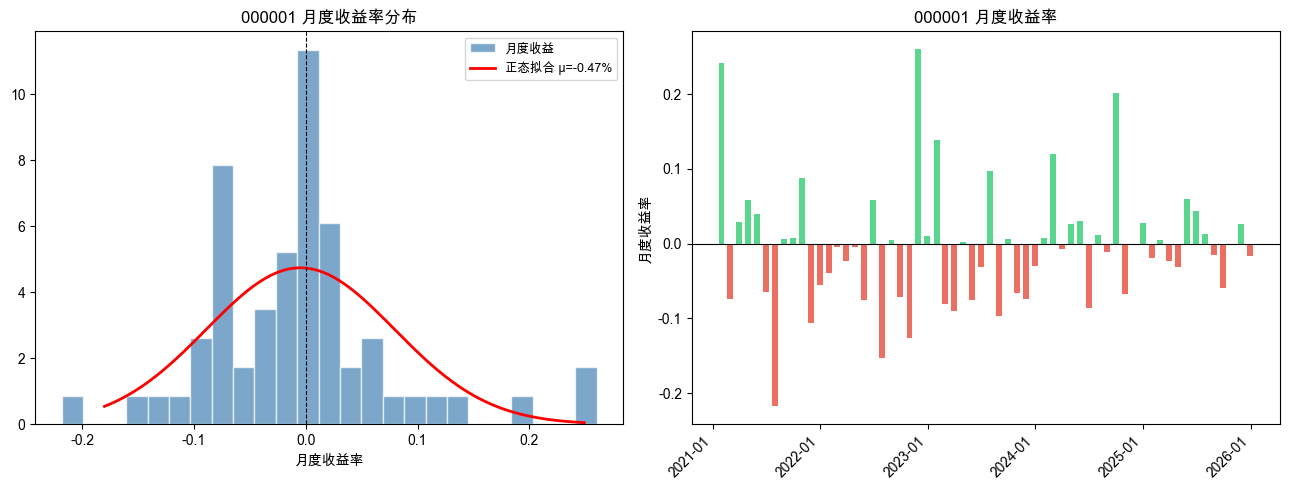

In [5]:
import scipy.stats as stats

# 月度收益率分布
daily_ret = calc_returns(close)
monthly_ret = (1 + daily_ret).resample("ME").prod() - 1  # ME = 月末

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 直方图
ax = axes[0]
ax.hist(monthly_ret.dropna(), bins=25, color="steelblue", edgecolor="white",
        alpha=0.7, density=True, label="月度收益")
mu, sigma = monthly_ret.mean(), monthly_ret.std()
x = np.linspace(monthly_ret.quantile(0.01), monthly_ret.quantile(0.99), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color="red", linewidth=2,
        label=f"正态拟合 μ={mu:.2%}")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"{SYMBOL} 月度收益率分布")
ax.set_xlabel("月度收益率")
ax.legend(fontsize=9)

# 月度收益时序条形图
ax2 = axes[1]
colors_m = ["#e74c3c" if v < 0 else "#2ecc71" for v in monthly_ret]
ax2.bar(monthly_ret.index, monthly_ret.values, color=colors_m, alpha=0.8, width=20)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title(f"{SYMBOL} 月度收益率")
ax2.set_ylabel("月度收益率")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

print(f"月度收益统计: 均值={mu:.2%}, 标准差={sigma:.2%}")
print(f"偏度={monthly_ret.skew():.3f}, 峰度={monthly_ret.kurt():.3f}")
plt.tight_layout()
plt.show()

---
## Section 2 — 财务数据分析

从 `utils.fundamental_loader` 加载估值和财务数据，绘制：
- PE/PB 历史趋势（相对估值判断高低）
- ROE 和毛利率趋势（盈利质量判断）

In [6]:
# 估值数据（PE/PB/PCF 时序）
try:
    val_df = df[['pe_ttm', 'pb', 'ps_ttm', 'pcf']].copy()  # 直接从本地数据取
    val_df = val_df.replace(0, float('nan'))  # 0 值视为缺失
    HAS_VALUATION = True
    print(f"✅ 估值数据加载成功: {val_df.shape}")
    print(val_df.tail(3))
except Exception as e:
    HAS_VALUATION = False
    print(f"⚠ 估值数据不可用: {e}")

# 财务数据（ROE/毛利率/负债率 季报）— 本地 CSV 不含财务数据
HAS_FINANCIALS = False
print('⚠ 本地 CSV 不含财务数据，Section 2.2 跳过')

✅ 估值数据加载成功: (1212, 4)
              pe_ttm        pb    ps_ttm       pcf
date                                              
2025-12-29  5.202756  0.500768  1.652164 -5.113106
2025-12-30  5.166750  0.497302  1.640730 -5.077721
2025-12-31  5.135246  0.494270  1.630725 -5.046760
⚠ 本地 CSV 不含财务数据，Section 2.2 跳过


PE_TTM: 当前=5.14x | 中位=5.26x | 分位=44%
PB: 当前=0.49x | 中位=0.59x | 分位=12%


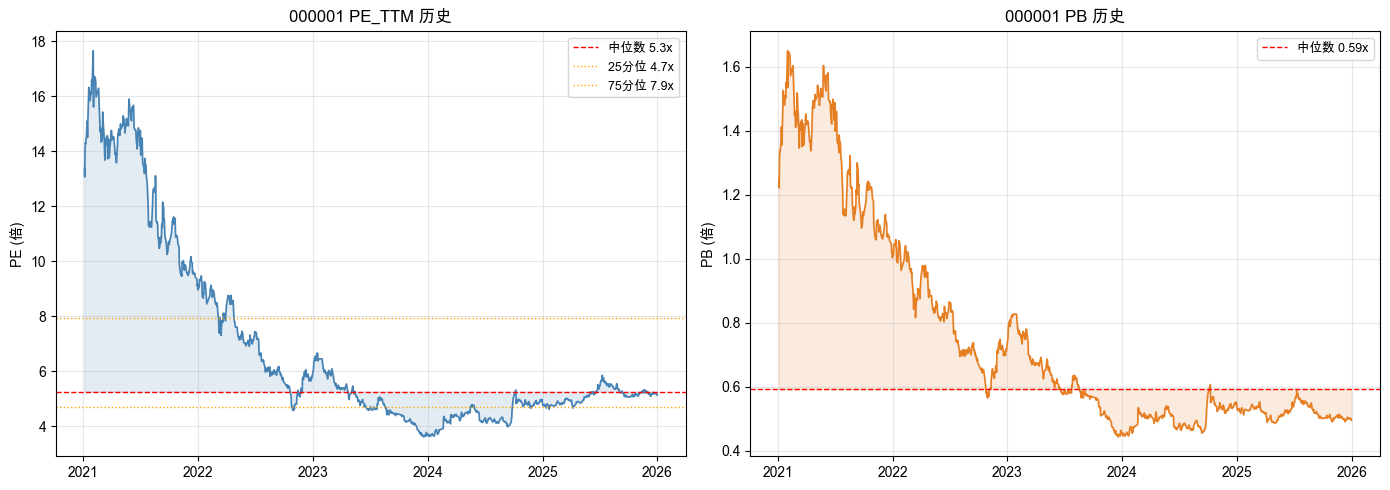

In [7]:
if HAS_VALUATION:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # PE_TTM 历史
    if "pe_ttm" in val_df.columns:
        ax = axes[0]
        pe = val_df["pe_ttm"].dropna()
        ax.plot(pe.index, pe, color="steelblue", linewidth=1.2)
        ax.fill_between(pe.index, pe, pe.median(), alpha=0.15, color="steelblue")
        ax.axhline(pe.median(), color="red", linestyle="--", linewidth=1,
                   label=f"中位数 {pe.median():.1f}x")
        ax.axhline(pe.quantile(0.25), color="orange", linestyle=":", linewidth=1,
                   label=f"25分位 {pe.quantile(0.25):.1f}x")
        ax.axhline(pe.quantile(0.75), color="orange", linestyle=":", linewidth=1,
                   label=f"75分位 {pe.quantile(0.75):.1f}x")
        ax.set_title(f"{SYMBOL} PE_TTM 历史")
        ax.set_ylabel("PE (倍)")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        print(f"PE_TTM: 当前={pe.iloc[-1]:.2f}x | 中位={pe.median():.2f}x | 分位={stats.percentileofscore(pe, pe.iloc[-1]):.0f}%")

    # PB 历史
    if "pb" in val_df.columns:
        ax = axes[1]
        pb = val_df["pb"].dropna()
        ax.plot(pb.index, pb, color="#e67e22", linewidth=1.2)
        ax.fill_between(pb.index, pb, pb.median(), alpha=0.15, color="#e67e22")
        ax.axhline(pb.median(), color="red", linestyle="--", linewidth=1,
                   label=f"中位数 {pb.median():.2f}x")
        ax.set_title(f"{SYMBOL} PB 历史")
        ax.set_ylabel("PB (倍)")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        print(f"PB: 当前={pb.iloc[-1]:.2f}x | 中位={pb.median():.2f}x | 分位={stats.percentileofscore(pb, pb.iloc[-1]):.0f}%")

    plt.tight_layout()
    plt.show()
else:
    print("跳过估值图（数据不可用）")

In [8]:
if HAS_FINANCIALS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROE 趋势
    roe_col = [c for c in fin_df.columns if "roe" in c.lower()]
    if roe_col:
        ax = axes[0]
        roe = fin_df[roe_col[0]].dropna()
        ax.plot(roe.index, roe, color="#2ecc71", linewidth=1.5, marker="o",
                markersize=4, label="ROE")
        ax.axhline(roe.mean(), color="red", linestyle="--", linewidth=1,
                   label=f"均值 {roe.mean():.2f}%")
        ax.set_title(f"{SYMBOL} ROE 趋势")
        ax.set_ylabel("ROE (%)")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    # 毛利率趋势
    gm_col = [c for c in fin_df.columns if "gross" in c.lower() or "毛利" in c.lower()]
    if gm_col:
        ax = axes[1]
        gm = fin_df[gm_col[0]].dropna()
        ax.plot(gm.index, gm, color="#9b59b6", linewidth=1.5, marker="o",
                markersize=4, label="毛利率")
        ax.axhline(gm.mean(), color="red", linestyle="--", linewidth=1,
                   label=f"均值 {gm.mean():.2f}%")
        ax.set_title(f"{SYMBOL} 毛利率趋势")
        ax.set_ylabel("毛利率 (%)")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    elif len(axes) > 1:
        axes[1].text(0.5, 0.5, "无毛利率列", ha="center", va="center",
                     transform=axes[1].transAxes, fontsize=12)

    print(f"财务数据列：{list(fin_df.columns)}")
    plt.tight_layout()
    plt.show()
else:
    print("跳过财务图（数据不可用）")

跳过财务图（数据不可用）


---
## Section 3 — 因子暴露分析

计算该股票在四大经典因子上的暴露程度：

| 因子 | 计算方法 | 含义 |
|------|----------|------|
| 动量 | 20日滚动收益率 | 近期价格趋势 |
| 价值 (EP) | 1/PE_TTM | 估值便宜程度 |
| 质量 (ROE) | 季报 ROE | 盈利能力 |
| 低波动 | 20日滚动年化波动率 | 价格稳定性 |

In [9]:
# 动量因子：20日滚动收益率
momentum_20 = close.pct_change(20).rename("momentum_20d")

# 价值因子：EP = 1/PE_TTM
if HAS_VALUATION and "pe_ttm" in val_df.columns:
    ep = (1.0 / val_df["pe_ttm"]).rename("EP")
    ep = ep.replace([np.inf, -np.inf], np.nan)
    # 对齐到 close 的索引（forward-fill）
    ep = ep.reindex(close.index).ffill()
    HAS_EP = True
else:
    ep = pd.Series(np.nan, index=close.index, name="EP")
    HAS_EP = False
    print("⚠ EP 因子：估值数据不可用，显示为空")

# 质量因子：ROE（季报对齐到日线）
if HAS_FINANCIALS:
    roe_col = [c for c in fin_df.columns if "roe" in c.lower()]
    if roe_col:
        roe_daily = fin_df[roe_col[0]].reindex(close.index).ffill().rename("ROE")
        HAS_ROE = True
    else:
        roe_daily = pd.Series(np.nan, index=close.index, name="ROE")
        HAS_ROE = False
else:
    roe_daily = pd.Series(np.nan, index=close.index, name="ROE")
    HAS_ROE = False
    print("⚠ ROE 因子：财务数据不可用，显示为空")

# 低波动因子：20日滚动年化波动率
daily_ret_s = calc_returns(close)
realized_vol = (daily_ret_s.rolling(20).std() * np.sqrt(252)).rename("realized_vol")

print(f"动量因子有效数据: {momentum_20.dropna().shape[0]} 行")
print(f"EP 因子有效数据: {ep.dropna().shape[0]} 行")
print(f"ROE 因子有效数据: {roe_daily.dropna().shape[0]} 行")
print(f"低波动因子有效数据: {realized_vol.dropna().shape[0]} 行")

⚠ ROE 因子：财务数据不可用，显示为空
动量因子有效数据: 1192 行
EP 因子有效数据: 1212 行
ROE 因子有效数据: 0 行
低波动因子有效数据: 1192 行


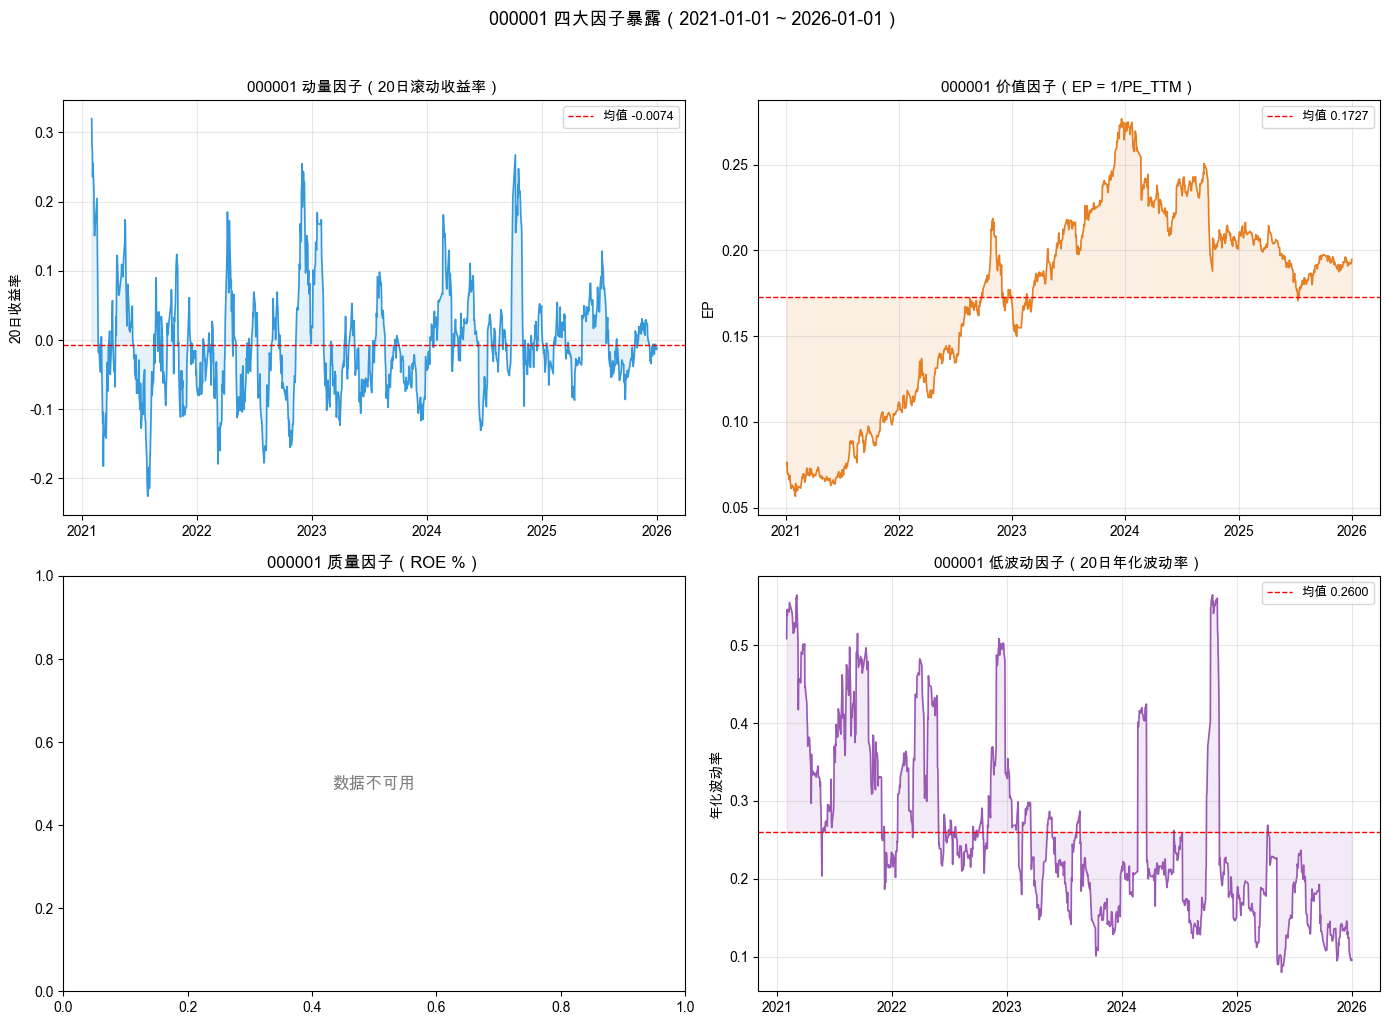

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def _plot_factor(ax, series, title, ylabel, color="steelblue"):
    """绘制因子时序辅助函数"""
    s = series.dropna()
    if s.empty:
        ax.text(0.5, 0.5, "数据不可用", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="gray")
        ax.set_title(title)
        return
    ax.plot(s.index, s, color=color, linewidth=1.2)
    ax.fill_between(s.index, s, s.mean(), alpha=0.12, color=color)
    ax.axhline(s.mean(), color="red", linestyle="--", linewidth=1,
               label=f"均值 {s.mean():.4f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# 左上：动量
_plot_factor(axes[0, 0], momentum_20,
             f"{SYMBOL} 动量因子（20日滚动收益率）",
             "20日收益率", color="#3498db")

# 右上：价值 (EP)
_plot_factor(axes[0, 1], ep,
             f"{SYMBOL} 价值因子（EP = 1/PE_TTM）",
             "EP", color="#e67e22")

# 左下：质量 (ROE)
_plot_factor(axes[1, 0], roe_daily,
             f"{SYMBOL} 质量因子（ROE %）",
             "ROE (%)", color="#2ecc71")

# 右下：低波动
_plot_factor(axes[1, 1], realized_vol,
             f"{SYMBOL} 低波动因子（20日年化波动率）",
             "年化波动率", color="#9b59b6")

plt.suptitle(f"{SYMBOL} 四大因子暴露（{START} ~ {END}）",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# 因子暴露汇总表
factor_data = {
    "动量_20日":  momentum_20,
    "价值_EP":    ep,
    "质量_ROE":   roe_daily,
    "低波动":      realized_vol,
}

rows = []
for name, s in factor_data.items():
    s_clean = s.dropna()
    if s_clean.empty:
        rows.append({"因子": name, "最新值": np.nan, "均值": np.nan,
                     "当前分位(%)": np.nan, "有效天数": 0})
    else:
        latest = s_clean.iloc[-1]
        pct = float(np.mean(s_clean <= latest)) * 100
        rows.append({"因子": name, "最新值": round(latest, 4),
                     "均值": round(s_clean.mean(), 4),
                     "当前分位(%)": round(pct, 1),
                     "有效天数": len(s_clean)})

summary = pd.DataFrame(rows)
print(f"\n{SYMBOL} 因子暴露汇总（截至数据末端）")
print(summary.to_string(index=False))


000001 因子暴露汇总（截至数据末端）
    因子     最新值      均值  当前分位(%)  有效天数
动量_20日 -0.0121 -0.0074     52.2  1192
 价值_EP  0.1947  0.1727     56.0  1212
质量_ROE     NaN     NaN      NaN     0
   低波动  0.0955  0.2600      1.1  1192


---
## Section 4 — AI 综合分析（可选）

使用 `agents.debate.BullBearDebate` 对该股票进行多空辩论分析。

> **注意**：此节需要 LLM 后端（`claude -p` 或 Ollama），如果后端不可用会自动跳过，不影响前面的分析结果。

In [12]:
try:
    from agents.debate import BullBearDebate
    from agents.base import LLMClient

    # 构建上下文摘要
    ctx_parts = [f"股票代码: {SYMBOL}"]
    ctx_parts.append(f"时间范围: {START} ~ {END}")

    # 价格信息
    if len(close) > 0:
        total_ret = (close.iloc[-1] / close.iloc[0] - 1)
        ctx_parts.append(f"区间涨跌幅: {total_ret:.2%}")
        ctx_parts.append(f"年化波动率: {float(realized_vol.dropna().mean()):.2%}")

    # 估值信息
    if HAS_VALUATION and "pe_ttm" in val_df.columns:
        pe_now = val_df["pe_ttm"].dropna().iloc[-1]
        ctx_parts.append(f"当前PE_TTM: {pe_now:.2f}x")
    if HAS_VALUATION and "pb" in val_df.columns:
        pb_now = val_df["pb"].dropna().iloc[-1]
        ctx_parts.append(f"当前PB: {pb_now:.2f}x")

    # 财务信息
    if HAS_ROE:
        roe_now = roe_daily.dropna().iloc[-1]
        ctx_parts.append(f"最新ROE: {roe_now:.2f}%")

    # 动量信息
    mom_now = momentum_20.dropna().iloc[-1]
    ctx_parts.append(f"近20日动量: {mom_now:.2%}")

    context_str = "\n".join(ctx_parts)
    print("=" * 50)
    print("输入上下文:")
    print(context_str)
    print("=" * 50)

    # 启动辩论
    llm = LLMClient()
    debate = BullBearDebate(llm)
    result = debate.analyze(
        topic=f"{SYMBOL} 股票投资价值分析",
        context=context_str,
    )
    report = debate.format_report(result)
    print("\n" + report)

except ImportError as e:
    print(f"⚠️ LLM 后端不可用，跳过 AI 分析（{e}）")
except Exception as e:
    err_msg = str(e).lower()
    if any(k in err_msg for k in ["connection", "connect", "timeout", "refused", "backend", "api"]):
        print(f"⚠️ LLM 后端不可用，跳过 AI 分析\n  原因: {e}")
    else:
        raise

输入上下文:
股票代码: 000001
时间范围: 2021-01-01 ~ 2026-01-01
区间涨跌幅: -38.66%
年化波动率: 26.00%
当前PE_TTM: 5.14x
当前PB: 0.49x
近20日动量: -1.21%



**topic**: 000001 股票投资价值分析

### bull_arguments
- 极度低估的估值水平提供充足安全边际：当前PE_TTM仅5.14倍，PB仅0.49倍，意味着市场定价低于净资产的一半。历史上平安银行PB中枢约0.8-1.0倍，当前估值处于历史极端底部区域。即使盈利零增长，仅估值均值回归至0.7倍PB，股价就有约43%的上行空间。破净状态本身也为大股东增持、回购注销等市值管理行为提供了强催化。
- 区间大幅下跌后的逆向机会与银行业政策顺风：股价自2021年以来累计下跌38.66%，大量悲观预期（房地产风险敞口、息差收窄、经济放缓）已充分定价。当前银行板块正受益于多重政策利好——存款利率多轮下调改善息差、房地产纾困政策降低资产质量尾部风险、监管鼓励银行加大分红力度提升股东回报。以5.14倍PE估算，对应股息率约5%-6%，在低利率环境下具备显著的类固收配置价值。
- 零售银行转型的成长性尚未被市场定价：平安银行背靠平安集团的综合金融生态和科技能力，零售业务AUM持续增长，财富管理和信用卡业务构建了差异化竞争壁垒。26%的年化波动率表明市场对其定价存在较大分歧，一旦零售转型成果在ROE层面兑现（目标ROE从当前约10%提升至12%+），估值体系将从传统银行的0.5倍PB切换至零售银行的0.8-1.0倍PB，带来估值与盈利的戴维斯双击。

### rebuttals
- 反驳1：低估值≠安全边际，可能是'价值陷阱'。PB仅0.49倍恰恰反映市场对其资产质量的深度担忧，而非市场犯错。平安银行涉房贷款、城投敞口和消费贷不良率持续承压，账面净资产可能存在高估——若将关注类贷款和逾期贷款充分计提，实际PB可能接近0.7-0.8倍，所谓'破净'的安全边际大幅缩水。历史PB中枢0.8-1.0倍对应的是ROE 15%+的时代，当前ROE已降至约10%且仍在下行通道，用历史中枢做均值回归锚点属于刻舟求剑。大股东增持和回购在A股银行中从未实质性改变长期估值趋势，仅提供短期脉冲。
- 反驳2：'悲观预期已充分定价'是一个无法证伪的说法，而风险仍在暴露中。房地产纾困政策落地效果远不及预期，2025年商品房销售面积仍在同比下滑，开发商违约尚未出清，平安银行对房地产相关敞口（含开发贷、按揭、供应链）的风险释放可能持续2-3年。息差方面，虽然存款利率下调，但LPR持续下

---

## 分析完成 ✅

| 模块 | 状态 |
|------|------|
| 价格与成交量 | ✅ |
| PE/PB 历史 | 取决于网络/缓存 |
| ROE/毛利率 | 取决于网络/缓存 |
| 因子暴露 2×2 | ✅ |
| AI 牛熊辩论 | 取决于 LLM 后端 |

### 下一步
- 修改 Section 0 的 `SYMBOL` 切换分析标的
- 结合 `04_portfolio_construction.ipynb`（待建）进行组合构建
- 因子分析深度研究见 `research/factors/` 各子模块